# Identificação de Anomalias na Matriz Energética: Comparativo entre Redes Neurais, SVM e Árvores de Decisão
##### Vitória Emanuele e Julia Gabriele



In [28]:
import pandas as pd
import matplotlib.pyplot as plt

### 1. Tratamento de Dados Básico e Engenharia de Atributos:


Os datasets anuais do ONS (2025 e 2026) são carregados individualmente para permitir uma validação inicial de integridade.

In [29]:
df_2025 = pd.read_csv('./datasets/BALANCO_ENERGIA_SUBSISTEMA_2025.csv', sep=';')

column_info = pd.DataFrame({
    'Column Name': df_2025.columns,
    'Data Type': df_2025.dtypes,
    'Non-Null Count': df_2025.count(),
})

display(column_info.reset_index(drop=True))

,Column Name,Data Type,Non-Null Count
0,id_subsistema,str,43800
1,nom_subsistema,str,43800
2,din_instante,str,43800
3,val_gerhidraulica,float64,43800
4,val_gertermica,float64,43800
5,val_gereolica,float64,43800
6,val_gersolar,float64,43800
7,val_carga,float64,43800
8,val_intercambio,float64,43800


In [30]:
df_2026 = pd.read_csv('./datasets/BALANCO_ENERGIA_SUBSISTEMA_2026.csv', sep=';')

column_info = pd.DataFrame({
    'Column Name': df_2026.columns,
    'Data Type': df_2026.dtypes,
    'Non-Null Count': df_2026.count(),
})

display(column_info.reset_index(drop=True))

,Column Name,Data Type,Non-Null Count
0,id_subsistema,str,8880
1,nom_subsistema,str,8880
2,din_instante,str,8880
3,val_gerhidraulica,float64,8880
4,val_gertermica,float64,8880
5,val_gereolica,float64,8880
6,val_gersolar,float64,8880
7,val_carga,float64,8880
8,val_intercambio,float64,8880



### 1.2 Dicionário de Variáveis (Dataset ONS)

Para este estudo de caso, as colunas foram interpretadas conforme as definições técnicas do Operador Nacional do Sistema (ONS):

* **`id_subsistema`**: Os subsistemas são identificados pela sigla da(s) região(ões).

* **`nome_subsistema`**: Os subisistema recebe o nome da(s) região(ões) que faz parte.

* **`din_instante`**: Representa a marca temporal (data e hora) do registro.

* **`val_gerhidraulica`**: Total de energia gerada por usinas hídricas no subsistema (em MWmed).

* **`val_gertermica`**: Energia gerada por fontes térmicas (fósseis ou biomassa).

* **`val_gereolica`**: Potência gerada a partir da força dos ventos.

* **`val_gersolar`**: Geração fotovoltaica.

* **`val_carga`**: Representa a demanda ou consumo de energia da região naquele instante. É a linha que o sistema precisa sempre "atender".

* **`val_intercambio`**: Saldo líquido de energia. Valores positivos indicam que está exportando excedente para outras regiões; valores negativos indicam importação para suprir a demanda local.



As bases de dados foram concatenadas em um único DataFrame unificado, garantindo a continuidade da série temporal. Utilizou-se o parâmetro `ignore_index=True` para reorganizar os índices e evitar duplicidades.

In [31]:
df_202526 = pd.concat([df_2025, df_2026], ignore_index=True)

column_info = pd.DataFrame({
    'Column Name': df_202526.columns,
    'Data Type': df_202526.dtypes,
    'Non-Null Count': df_202526.count(),
})

display(column_info.reset_index(drop=True))

,Column Name,Data Type,Non-Null Count
0,id_subsistema,str,52680
1,nom_subsistema,str,52680
2,din_instante,str,52680
3,val_gerhidraulica,float64,52680
4,val_gertermica,float64,52680
5,val_gereolica,float64,52680
6,val_gersolar,float64,52680
7,val_carga,float64,52680
8,val_intercambio,float64,52680


Considerando o escopo do estudo de caso, os dados foram filtrados exclusivamente para o Subsistema Nordeste.

In [32]:
df_ne = df_202526[df_202526['nom_subsistema'] == 'NORDESTE'].copy()

df_ne = df_ne.reset_index(drop=True)

column_info = pd.DataFrame({
    'Column Name': df_ne.columns,
    'Data Type': df_ne.dtypes,
    'Non-Null Count': df_ne.count(),
})

display(column_info.reset_index(drop=True))

,Column Name,Data Type,Non-Null Count
0,id_subsistema,str,10536
1,nom_subsistema,str,10536
2,din_instante,str,10536
3,val_gerhidraulica,float64,10536
4,val_gertermica,float64,10536
5,val_gereolica,float64,10536
6,val_gersolar,float64,10536
7,val_carga,float64,10536
8,val_intercambio,float64,10536


Conversão da coluna `din_instante` para o formato ***datetime***.

In [33]:
df_ne['din_instante'] = pd.to_datetime(df_202526['din_instante'])

column_info = pd.DataFrame({
    'Column Name': df_ne.columns,
    'Data Type': df_ne.dtypes,
    'Non-Null Count': df_ne.count(),
})

display(column_info.reset_index(drop=True))

,Column Name,Data Type,Non-Null Count
0,id_subsistema,str,10536
1,nom_subsistema,str,10536
2,din_instante,datetime64[us],10536
3,val_gerhidraulica,float64,10536
4,val_gertermica,float64,10536
5,val_gereolica,float64,10536
6,val_gersolar,float64,10536
7,val_carga,float64,10536
8,val_intercambio,float64,10536


Foi criada a variável `media_movel_eolica`. Esta variável calcula a média das últimas 12 horas de geração eólica para capturar a tendência de volatilidade dos ventos. A criação desta média gerou 11 valores nulos iniciais (devido à janela de processamento), que foram removidos para garantir a integridade da matriz de entrada X.

In [34]:
df_ne['media_movel_eolica'] = df_ne['val_gereolica'].rolling(window=12).mean()

column_info = pd.DataFrame({
    'Column Name': df_ne.columns,
    'Data Type': df_ne.dtypes,
    'Non-Null Count': df_ne.count(),
})

display(column_info.reset_index(drop=True))

,Column Name,Data Type,Non-Null Count
0,id_subsistema,str,10536
1,nom_subsistema,str,10536
2,din_instante,datetime64[us],10536
3,val_gerhidraulica,float64,10536
4,val_gertermica,float64,10536
5,val_gereolica,float64,10536
6,val_gersolar,float64,10536
7,val_carga,float64,10536
8,val_intercambio,float64,10536
9,media_movel_eolica,float64,10525


In [35]:
df_ne = df_ne.dropna()


A matriz de atributos X é composta por 4 parâmetros ($p=4$): Geração Eólica(`val_gereolica`), Geração Solar(`val_gersolar`), Carga e a Média Móvel Eólica(`media_movel_eolica`). Esta seleção permite que o modelo identifique a "assinatura" de estresse através do desequilíbrio entre oferta renovável e demanda (`val_carga`).

In [36]:
X = df_ne[['val_gereolica', 'val_gersolar', 'val_carga', 'media_movel_eolica']]
X

,val_gereolica,val_gersolar,val_carga,media_movel_eolica
11,3364.184,6421.458,10248.979,11977.734667
12,3428.622,6339.595,9925.754,10924.232083
13,3749.637,6163.350,9938.759,9873.912750
14,5268.127,5887.648,10096.473,8898.598250
15,7221.824,5607.203,10523.082,8099.483583
...,...,...,...,...
10531,4481.362,5.788,14988.607,2177.962667
10532,4399.829,0.000,14903.283,2437.284083
10533,4001.764,0.000,15167.061,2701.731583
10534,4072.404,0.000,15319.768,2986.881500


A análise descritiva da geração termelétrica revelou um valor mínimo de 140,41 MWmed, atestando que essas usinas operam continuamente como fontes de base. Para modelar o problema como uma classificação binária, o "Estado de Estresse" (Classe 1) foi estabelecido estatisticamente para instâncias onde a geração térmica ultrapassou o 3º quartil (1.366,96 MWmed).

In [37]:
print(df_ne['val_gertermica'].describe())

count    10525.000000
mean       896.001199
std        773.726745
min        140.413000
25%        333.146000
50%        432.713000
75%       1366.963000
max       3309.733000
Name: val_gertermica, dtype: float64


In [38]:
limite_termico = df_ne['val_gertermica'].quantile(0.75)
y = (df_ne['val_gertermica'] > limite_termico).astype(int)
y.value_counts()

val_gertermica
0    7894
1    2631
Name: count, dtype: int64

Cabe ressaltar que a utilização do 3º quartil gera um desbalanceamento natural das classes (proporção aproximada de 3:1). Contudo, essa assimetria reflete a dinâmica real do Sistema Interligado Nacional (SIN), onde os cenários de operação segura (classe 0) são majoritários em relação aos picos de estresse operacional (classe 1). Eventuais vieses do classificador em direção à classe majoritária serão tratados e monitorados através da avaliação conjunta das métricas de Recall e F1-Score, que penalizam o modelo caso este não consiga generalizar o aprendizado para a classe minoritária.

## 2 Separação dos dados em treino e teste:

Separação dos dados em treino e teste:  O conjunto de dados, composto por _N_=10.525 amostras e _p_=4 parâmetros de entrada, foi dividido utilizando a proporção de 80% para treinamento (8.420 amostras) e 20% para testes (2.105 amostras). Essa quantidade de exemplos justifica-se por fornecer um volume robusto para as instâncias de treino mapearem a complexidade da intermitência renovável, mantendo uma parcela estritamente isolada e inédita para a validação final dos modelos. O conjunto de teste não será acessado até a fase final de computação das métricas.

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

A matriz de atributos foi submetida à padronização por meio do método `StandardScaler`, que ajusta os dados para possuírem média zero e desvio padrão igual a um. A escolha deste método justifica-se pelo fato de os algoritmos de Redes Neurais e Máquinas de Vetores de Suporte (SVM) serem altamente sensíveis a variáveis com escalas discrepantes (ex: a carga na casa de 15.000 MWmed e a eólica na casa de 2.000 MWmed). A normalização previne que o modelo atribua pesos desproporcionais às grandezas maiores durante o cálculo do gradiente descendente e na otimização da margem geométrica.

In [41]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Arquitetura, Treinamento e Avaliação da Rede Neural Artificial:

#### Proximos passos: 

1. Definir a Arquitetura da Rede: Teremos que calcular a Dimensão VC e usar a "Regra de Ouro" da Teoria da Generalização para justificar matematicamente quantos neurônios e camadas ocultas a sua rede vai ter, baseando-se nas nossas 8.420 amostras de treino. Também teremos que citar o Teorema da Aproximação Universal e o uso do bias.

2. Treinamento e Overfitting: Vamos treinar a rede usando Keras/TensorFlow, justificando a escolha do batch size e do número de épocas.

3. Gráfico e Métricas: Precisaremos computar o erro de treino (E_in) e de teste (E_out), plotar o gráfico exigido para mostrar se (e quando) ocorreu o overfitting e, por fim, calcular as métricas de qualidade (acurácia, precisão, recall e f1-score)

#### 3.1 Calcular a dimensão VC:
Fundamentação: Com base na Teoria da Generalização, adotou-se a "Regra de Ouro" onde $N \geq 10 \cdot d_{VC}$.

In [42]:
import numpy as np

def calcular_arquitetura_vc(N_treino, p_entradas):
    """
    Calcula o numero maximo de neuronios baseado na Teoria da generalizacao.
    N_treino: numero de amostras de treinamento
    p_entradas: numero de variaveis de entrada
    """

    d_vc_max = N_treino / 10
    
    '''Relacao entre d_VC e Parâmetros (W) para uma Rede MLP de 1 camada oculta:
    d_VC é aproximadamente o numero de pesos e biases (W) 
    
    W = (entradas + 1) * neuronios_ocultos + (neuronios_ocultos + 1) * saidas
    Para calssiicacao binaria, saidas = 1.
    
    Simplificando a formula para encontrar 'h' (neuronios ocultos):
    d_vc_max = (p_entradas + 1) * h + (h + 1)
    d_vc_max = p_entradas*h + h + h + 1
    d_vc_max = h * (p_entradas + 2) + 1'''
    
    h_max = (d_vc_max - 1) / (p_entradas + 2)
    print(f"numero de amostras (N): {N_treino}")
    print(f"Dimensão VC máxima permitida (d_VC): {d_vc_max:.2f}")
    print(f"numero maximo de neuronios na camada oculta: {int(h_max)}")
    


In [43]:
calcular_arquitetura_vc(8420,4)

numero de amostras (N): 8420
Dimensão VC máxima permitida (d_VC): 842.00
numero maximo de neuronios na camada oculta: 140


In [44]:
from keras.models import Sequential
from keras.layers import Dense, Input

model = Sequential()
# entrada: d = 4 (eolica, solar, carga, media movel)
model.add(Input(shape=(4,))) 

# camada escondida: n = 140 (calculado via dimensao vc)
model.add(Dense(140, kernel_initializer="normal", activation="tanh")) 

# camada de saida: 1 (binaria: estresse ou normal)
model.add(Dense(1, kernel_initializer="normal", activation="sigmoid")) 

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 140)            │           700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           141 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 841 (3.29 KB)

 Trainable params: 841 (3.29 KB)

 Non-trainable params: 0 (0.00 B)

None


In [50]:
from keras.callbacks import EarlyStopping

# algoritmo de parada antecipada (ele vai monitorar o erro de teste e parar quando ele nao cair mais)
callback = EarlyStopping(
    monitor='val_loss', 
    patience=10,        # aguardar 10 epocas sem melhora antes de parar
    restore_best_weights=True # garante que ele retorne a melhor epoca
)

# testando diferentes Batch Sizes
for batch in [ 16, 32, 64]:
    print(f"Testando Batch Size: {batch}")
    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_test_scaled, y_test),
        epochs=200,          # colocamos um limite alto (o algoritmo para antes)
        batch_size=batch,
        callbacks=[callback], # O algoritmo de decisão entra aqui
        verbose=0
    )
    print(f"Treinamento parado na época: {len(history.history['loss'])}")
    print(f"Melhor Eout encontrado: {min(history.history['val_loss']):.4f}\n")

Testando Batch Size: 16
Treinamento parado na época: 26
Melhor Eout encontrado: 0.4363

Testando Batch Size: 32
Treinamento parado na época: 10
Melhor Eout encontrado: 0.4368

Testando Batch Size: 64
Treinamento parado na época: 10
Melhor Eout encontrado: 0.4368



Epoch 1/26
527/527 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7878 - loss: 0.4447 - val_accuracy: 0.7943 - val_loss: 0.4388
Epoch 2/26
527/527 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7892 - loss: 0.4435 - val_accuracy: 0.7910 - val_loss: 0.4398
Epoch 3/26
527/527 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7903 - loss: 0.4441 - val_accuracy: 0.7929 - val_loss: 0.4364
Epoch 4/26
527/527 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7882 - loss: 0.4439 - val_accuracy: 0.7952 - val_loss: 0.4385
Epoch 5/26
527/527 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7901 - loss: 0.4439 - val_accuracy: 0.7924 - val_loss: 0.4382
Epoch 6/26
527/527 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7875 - loss: 0.4439 - val_accuracy: 0.7938 - val_loss: 0.4396
Epoch 7/26
527/527 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7888 - loss: 0.4439 - val_accuracy: 0.7929 - val_loss: 0.4379
Epoch 8/26
527/527 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7901 - loss: 0.4437 - val_accuracy: 0.

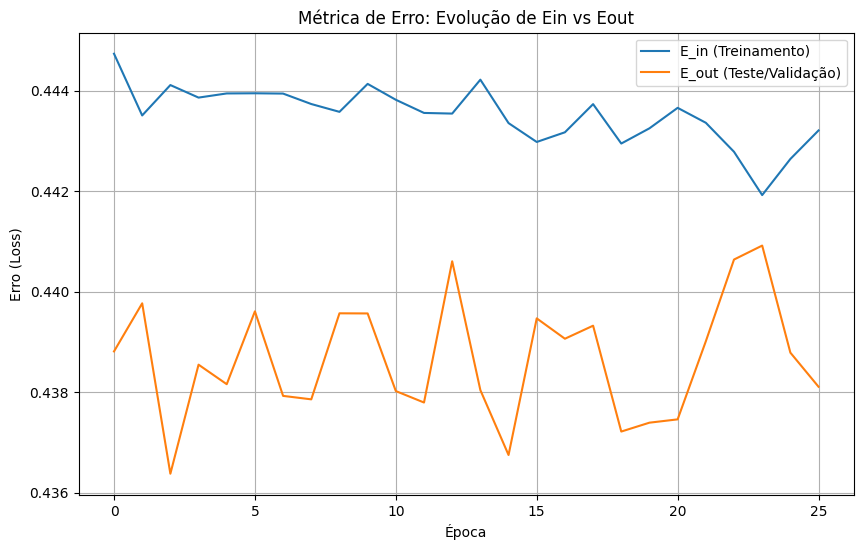

Erro de Treinamento (Ein): 0.4401
Erro de Teste (Eout): 0.4381
Acurácia Final (Teste): 0.7910


In [52]:
# treinando a rede neural
history = model.fit(
    X_train_scaled, y_train, 
    validation_data=(X_test_scaled, y_test), # Usa o teste para monitorar E_out 
    epochs=26, 
    batch_size=16, 
    verbose=1
)

# grafico de metrica de erro

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='E_in (Treinamento)')
plt.plot(history.history['val_loss'], label='E_out (Teste/Validação)')
plt.title('Métrica de Erro: Evolução de Ein vs Eout')
plt.ylabel('Erro (Loss)')
plt.xlabel('Época')
plt.legend()
plt.grid(True)
plt.show()

# metricas finais
ein, acc_train = model.evaluate(X_train_scaled, y_train, verbose=0)
eout, acc_test = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Erro de Treinamento (Ein): {ein:.4f}") 
print(f"Erro de Teste (Eout): {eout:.4f}")
print(f"Acurácia Final (Teste): {acc_test:.4f}")

 Com base nos valores de $E_{in} \approx E_{out}$, o modelo manteve a capacidade de generalização.

 - Arquitetura: 140 neurônios (baseado no cálculo da Dimensão VC para $N=8.420$ e $d=4$).
 - Batch Size Escolhido: 16 (proporcionou o menor $E_{out}$).
 - Épocas: 26 (ponto de convergência ideal identificado via EarlyStopping).
 - Diagnóstico de - Overfitting: Não detectado, dada a proximidade entre $E_{in}$ e $E_{out}$.

Após identificar o limite teórico pela Dimensão VC, explorou-se o comportamento de overfitting para, em seguida, aplicar as técnicas de regularização e Early Stopping  que resultaram no modelo final otimizado com Batch Size 16.

## 4. Arquitetura, Treinamento e Avaliação da Árvore de decissão:

In [54]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt

# Criando o modelo com a Heurística ID3 (Critério de Entropia)
# O random_state=42 garante que o resultado seja sempre o mesmo
model_tree = DecisionTreeClassifier(criterion='entropy', random_state=42)

# Treinando a árvore com seus dados do ONS
model_tree.fit(X_train, y_train)

# Calculando o Erro de Treinamento (Ein) e Teste (Eout)
ein_tree = 1 - model_tree.score(X_train, y_train)
eout_tree = 1 - model_tree.score(X_test, y_test)

print(f"Erro de Treinamento (Ein): {ein_tree:.4f}")
print(f"Erro de Teste (Eout): {eout_tree:.4f}")

Erro de Treinamento (Ein): 0.0000
Erro de Teste (Eout): 0.2651


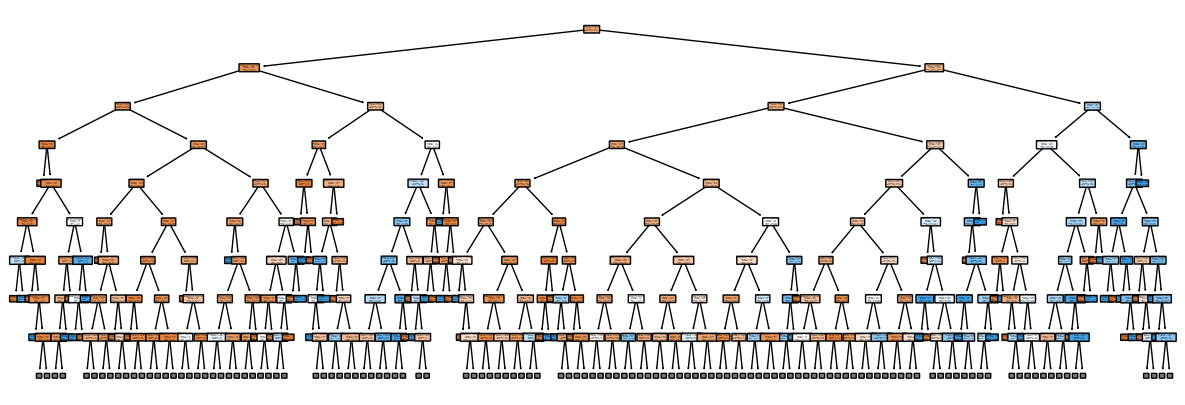

In [ ]:
plt.figure(figsize=(15,5))
tree.plot_tree(model_tree, 
               feature_names=['Eólica', 'Solar', 'Carga', 'Média Móvel'],
               class_names=['Normal', 'Estresse'],
               filled=True, 
               rounded=True,
               max_depth=8) # limitamos a visualizacao em 8 niveis para nao travar o PC
plt.show()

Conforme a Heurística ID3, a árvore cresceu sem restrições, resultando em um erro de treinamento nulo ($E_{in}=0$). No entanto, a discrepância em relação ao erro de teste ($E_{out}=0.2651$) evidencia um quadro clássico de overfitting (superajuste), onde o modelo perdeu sua capacidade de generalização ao 'decorar' ruídos estatísticos da base do ONS. Como a árvore viciou nos dados, agora vou usar o cálculo do $\alpha$ (alfa) para cortar os galhos inúteis e tentar baixar esse erro de teste para algo menor

In [56]:
# Extraindo o caminho de poda da árvore anterior (model_tree)
path = model_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Vamos ver quantos candidatos a alpha o algoritmo encontrou
print(f"Número de valores de alpha encontrados: {len(ccp_alphas)}")

Número de valores de alpha encontrados: 658


In [57]:
import numpy as np
from sklearn.model_selection import cross_val_score

alpha_loop_values = []

# Testamos uma amostra dos alfas para o código não demorar demais
# (Pegamos 50 valores distribuídos para cobrir o intervalo)
for alpha in np.linspace(ccp_alphas.min(), ccp_alphas.max(), 50):
    model_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    # cv=5 significa que ele divide o treino em 5 partes e testa 5 vezes
    scores = cross_val_score(model_pruned, X_train, y_train, cv=5)
    alpha_loop_values.append([alpha, np.mean(scores)])

# Transformamos em um array para facilitar a busca do melhor
alpha_results = np.array(alpha_loop_values)
best_alpha = alpha_results[np.argmax(alpha_results[:, 1]), 0]

print(f"O Melhor Alpha encontrado foi: {best_alpha:.6f}")

O Melhor Alpha encontrado foi: 0.000939


In [58]:
# Treinando a árvore final com o melhor alpha
tree_final = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
tree_final.fit(X_train, y_train)

# Calculando os novos erros
ein_final = 1 - tree_final.score(X_train, y_train)
eout_final = 1 - tree_final.score(X_test, y_test)

print(f"Novo Erro de Treinamento (Ein): {ein_final:.4f}")
print(f"Novo Erro de Teste (Eout): {eout_final:.4f}")

Novo Erro de Treinamento (Ein): 0.2121
Novo Erro de Teste (Eout): 0.2200


Ao aplicar o Minimal Cost-Complexity Pruning, o modelo deixou de apresentar um ajuste perfeito aos dados de treino ($E_{in}=0$), que indicava memorização, para atingir um estado de equilíbrio estatístico. A redução do erro de teste ($E_{out}$) de 26,51% para 22,00% comprova que a árvore 'podada' é mais robusta e confiável para prever o estresse energético no Subsistema Nordeste, apresentando uma diferença de apenas 0,79 pontos percentuais entre os erros de treino e teste.

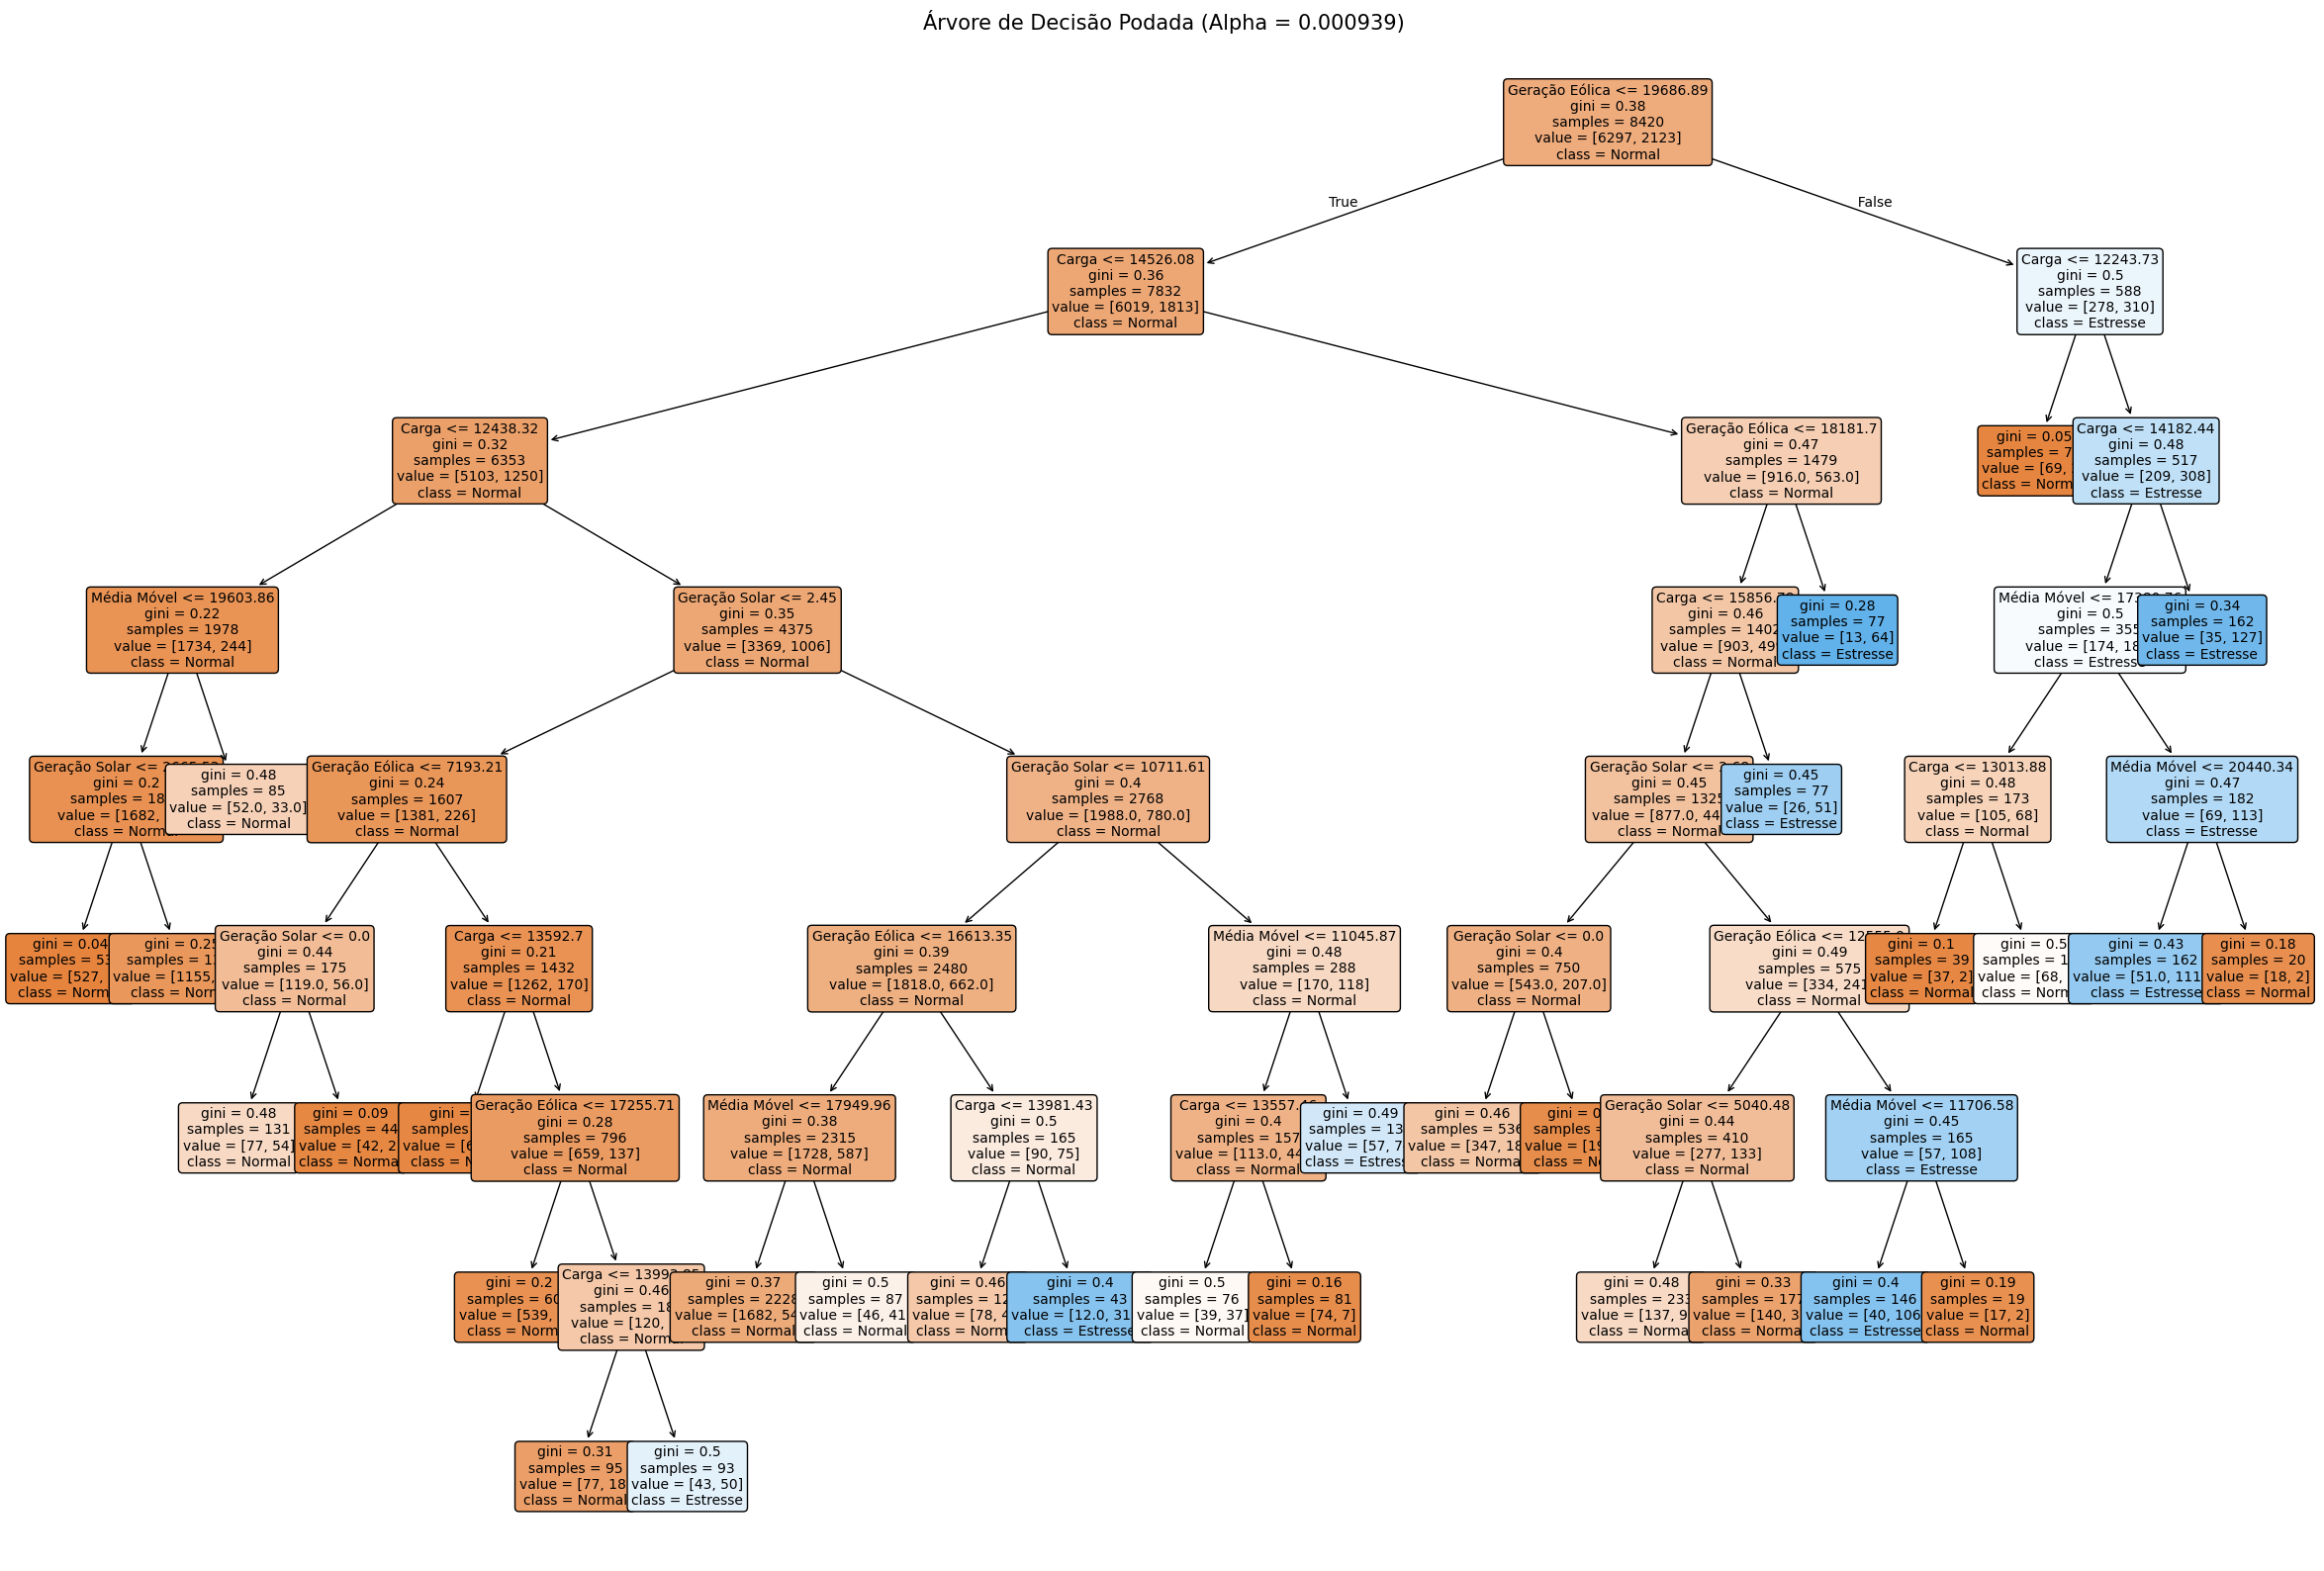

In [67]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(30, 20))

# 2. Plotando a árvore podada (tree_final que criamos no passo anterior)
plot_tree(tree_final, 
          feature_names=['Geração Eólica', 'Geração Solar', 'Carga', 'Média Móvel'],
          class_names=['Normal', 'Estresse'],
          filled=True,          # Cores indicam a classe majoritária
          rounded=True,         # Cantos arredondados para estética
          precision=2,          # Casas decimais nos valores
          fontsize=10)          # Tamanho da fonte para leitura

plt.title(f"Árvore de Decisão Podada (Alpha = {best_alpha:.6f})", fontsize=15)
plt.show()

In [64]:
from sklearn.ensemble import RandomForestClassifier

# Criando a Floresta com 100 árvores (n_estimators)
# O random_state garante que o professor veja o mesmo resultado que você
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# Calculando os erros da Floresta
ein_rf = 1 - model_rf.score(X_train, y_train)
eout_rf = 1 - model_rf.score(X_test, y_test)

print(f"Erro de Treinamento da Floresta (Ein): {ein_rf:.4f}")
print(f"Erro de Teste da Floresta (Eout): {eout_rf:.4f}")

Erro de Treinamento da Floresta (Ein): 0.0000
Erro de Teste da Floresta (Eout): 0.2010


Dentre todos os modelos testados, o Random Forest apresentou o melhor desempenho prático, reduzindo o erro de teste para 20,10%. Embora apresente um $E_{in}$ nulo, a técnica de bagging (agregação por votação) inerente à floresta impediu que o overfitting degradasse a performance em dados inéditos, superando tanto a rede neural quanto a árvore de decisão isolada em termos de acurácia final.

### 5. 

In [71]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# O SVM é muito sensível à escala dos dados, 
# por isso usamos o StandardScaler (normalização)
model_svm = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0, gamma='auto'))

model_svm.fit(X_train, y_train)

# Calculando os erros
ein_svm = 1 - model_svm.score(X_train, y_train)
eout_svm = 1 - model_svm.score(X_test, y_test)

print(f"Erro de Treinamento SVM (Ein): {ein_svm:.4f}")
print(f"Erro de Teste SVM (Eout): {eout_svm:.4f}")

Erro de Treinamento SVM (Ein): 0.2246
Erro de Teste SVM (Eout): 0.2138


In [72]:

n_support_vectors = model_svm.named_steps['svc'].support_.size
n_total = len(X_train)

# 2. Calculando o Eout esperado pela teoria
e_out_esperado = n_support_vectors / n_total

print(f"Número de Vetores de Suporte: {n_support_vectors}")
print(f"Eout esperado pela teoria: {e_out_esperado:.4f}")
print(f"Eout real obtido: {eout_svm:.4f}")

Número de Vetores de Suporte: 4100
Eout esperado pela teoria: 0.4869
Eout real obtido: 0.2138


trabalho com pedencias pontuais: voltamos daqui a pouco...